<a href="https://colab.research.google.com/github/VanishingPizza/Machine-Learning/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 1: Load the dataset into a Pandas DataFrame.

In [51]:
import pandas as pd
dataframe=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')



### Task 2: Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.

In [52]:
#View First 5 Rows
print("\n --- First 5 Rows --- ")
display(dataframe.head())
#View columns, number of entries that are not null, data type, etc
print("\n --- Dataframe Info---")
dataframe.info()
print("\n --- Summary Statistics---")
dataframe.describe()



 --- First 5 Rows --- 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



 --- Dataframe Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Task 3: Drop any non-informative identifiers (such as customerID).

In [68]:
#Create new dataframe with customerID dropped
df_cleaned=dataframe.drop("customerID",axis=1)
#Change TotalCharges from object to float because it is numerical feature
df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'], errors='coerce')
#Verify changes
df_cleaned.info()
print("\n --- First 5 Rows --- ")
display(df_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Task 4: Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [69]:
import numpy as np
from sklearn.impute import SimpleImputer
#Identify missing values across columns
missing = df_cleaned.isnull().sum()
print(missing)

#Quantify missing values, using mean
median = df_cleaned["TotalCharges"].median()
df_cleaned["TotalCharges"].fillna(median,inplace=True)
numeric_imputer = SimpleImputer(strategy="median")

#Verify changes
missing = df_cleaned.isnull().sum()
print('---Changed---')
print(missing)


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
---Changed---
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_759/799328209.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned["TotalCharges"].fillna(median,inplace=True)


### Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and encoding (OneHotEncoder) to categorical columns.

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier

# Identify numerical and categorical feature columns
numeric_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = ['gender','Partner', 'Dependents','PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod']

# Numerical transformation pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformation pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Assemble full pipeline with preprocessing and classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier())
])

print("Pipeline constructed successfully.")

Pipeline constructed successfully.


### Task 6: Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [74]:
# Assemble full pipeline with preprocessing and classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42))
])
print("Pipeline constructed successfully.")

Pipeline constructed successfully.


### Task 7: Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.

In [75]:
from sklearn.model_selection import train_test_split
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3, random_state=42)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.4, random_state=42)
print("--- 80/20 Train/Test Split Ratio ---")
print(f"First training features shape: {X_train.shape}")
print(f"First testing features shape: {X_test.shape}")
print("--- 70/30 Train/Test Split Ration ---")
print(f"Second training features shape: {X_train2.shape}")
print(f"Second testing features shape: {X_test2.shape}")
print("--- 60/40 Test Split Ratio ---")
print(f"Third training features shape: {X_train3.shape}")
print(f"Third testing features shape: {X_test3.shape}")

--- 80/20 Train/Test Split Ratio ---
First training features shape: (5634, 19)
First testing features shape: (1409, 19)
--- 70/30 Train/Test Split Ration ---
Second training features shape: (4930, 19)
Second testing features shape: (2113, 19)
--- 60/40 Test Split Ratio ---
Third training features shape: (4225, 19)
Third testing features shape: (2818, 19)


In [ ]:
from sklearn import set_config

# Enable diagram output for scikit-learn estimators and pipelines
set_config(display="diagram")

# Display the constructed pipeline
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 SGDClassifier(loss='log_loss', random_state=42))])

Classification Report For 80/20 Split:
              precision    recall  f1-score   support

          No       0.85      0.90      0.88      1036
         Yes       0.67      0.57      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



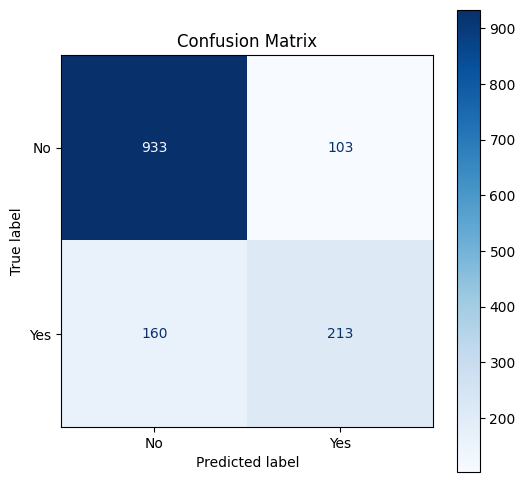

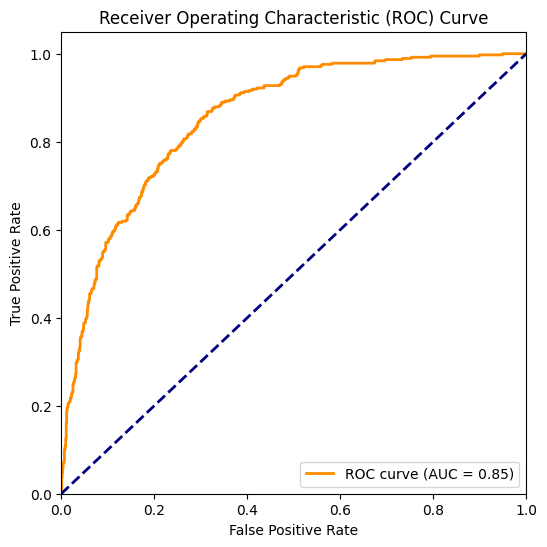

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# Fit the entire pipeline on the training data
pipeline.fit(X_train, y_train)

# Generate predictions and probability scores on the test set
y_pred = pipeline.predict(X_test)
y_scores = pipeline.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report For 80/20 Split:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Classification Report For 70/30 Split:
              precision    recall  f1-score   support

          No       0.79      0.96      0.87      1539
         Yes       0.74      0.32      0.45       574

    accuracy                           0.79      2113
   macro avg       0.77      0.64      0.66      2113
weighted avg       0.78      0.79      0.75      2113



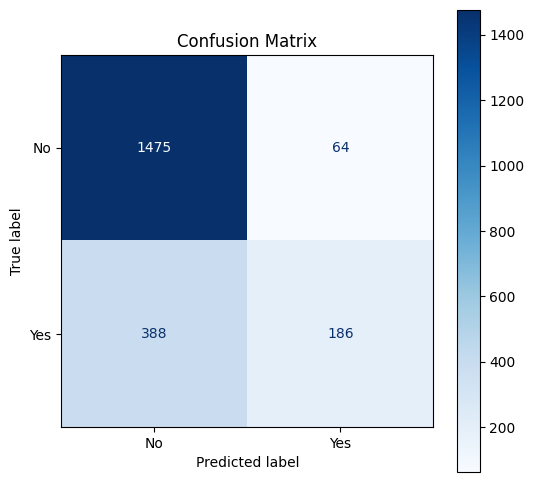

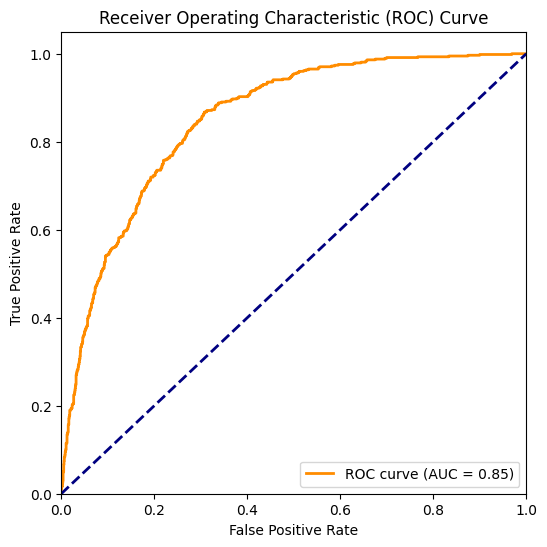

In [76]:

# Fit the entire pipeline on the training data
pipeline.fit(X_train2, y_train2)

# Generate predictions and probability scores on the test set
y_pred = pipeline.predict(X_test2)
y_scores = pipeline.predict_proba(X_test2)[:, 1]

# Print classification report
print("Classification Report For 70/30 Split:")
print(classification_report(y_test2, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test2, y_test2, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test2, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Classification Report For 60/40 Split:
              precision    recall  f1-score   support

          No       0.79      0.95      0.86      2069
         Yes       0.70      0.32      0.44       749

    accuracy                           0.78      2818
   macro avg       0.74      0.63      0.65      2818
weighted avg       0.77      0.78      0.75      2818



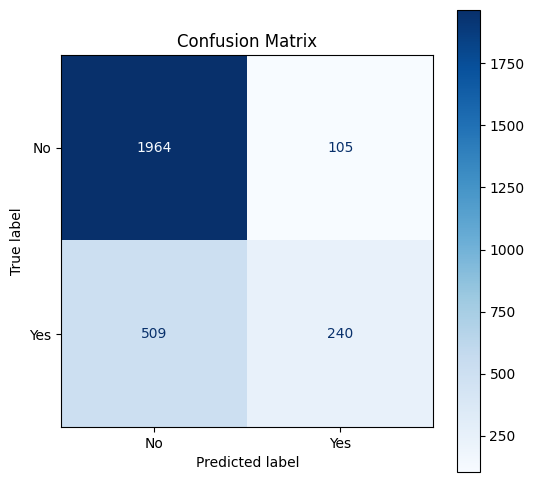

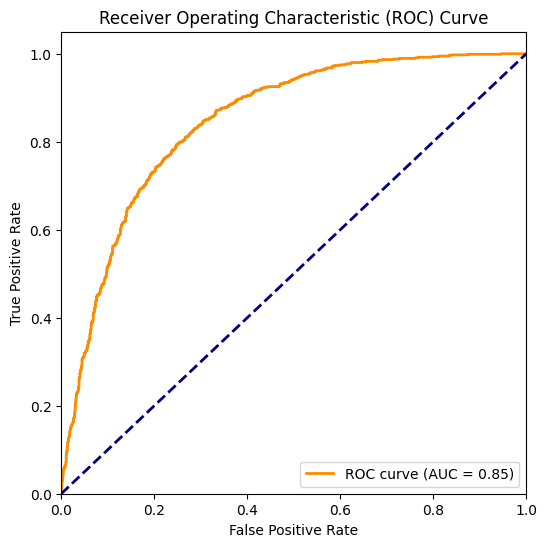

In [77]:


# Fit the entire pipeline on the training data
pipeline.fit(X_train3, y_train3)

# Generate predictions and probability scores on the test set
y_pred = pipeline.predict(X_test3)
y_scores = pipeline.predict_proba(X_test3)[:, 1]

# Print classification report
print("Classification Report For 60/40 Split:")
print(classification_report(y_test3, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test3, y_test3, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test3, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

From the three different train/split ratios, the 80/20 ratio had the highest accuracy with 81%.The 70/30 ratio had the second highest accuracy with 79%, and the 60/40 ratio had an accuracy of 78%.

### Task 8: Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.

In [79]:


# Extract feature names from the preprocessor step
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Combine numerical and encoded categorical feature names
all_feature_names = numeric_features + encoded_cat_features

# Retrieve coefficients from the SGDClassifier step
coefficients = pipeline.named_steps['classifier'].coef_[0]

# Create a DataFrame to view feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display top features pushing toward spam and non-spam
print("Top features pushing toward Churned customers:")
print(feature_importance_df.head(10))

print("\nTop features pushing toward Retained Customers:")
print(feature_importance_df.tail(10))

Top features pushing toward Churned customers:
                           Feature  Coefficient
36         Contract_Month-to-month     0.904470
16     InternetService_Fiber optic     0.736696
43  PaymentMethod_Electronic check     0.568223
3                     TotalCharges     0.539928
35             StreamingMovies_Yes     0.539428
27                  TechSupport_No     0.512759
10                 PhoneService_No     0.495349
13  MultipleLines_No phone service     0.495349
6                       Partner_No     0.491360
5                      gender_Male     0.488741

Top features pushing toward Retained Customers:
                                    Feature  Coefficient
23                         OnlineBackup_Yes     0.144840
20                       OnlineSecurity_Yes     0.111808
42    PaymentMethod_Credit card (automatic)     0.087263
29                          TechSupport_Yes     0.076108
33                       StreamingMovies_No     0.049439
12                         Multipl